## [LDA (Análise Discriminante Linear)](https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.LinearDiscriminantAnalysis.html)

Colab de referência: https://colab.research.google.com/drive/1KyyJUAWqp15cqjTF_YQeSdCHZTPA04ic



Características:
* Método de classificação que opera em um conjunto de dados de menor dimensão;
* Boa separabilidade de classes;
* Primeiro reduz a dimensionalidade do dataset para depois proceder com a classificação;
* Eficaz para problemas de classificação multiclasse;
* Método linear (computacionalmente eficiente);
* Funciona bem em cenários que as **classes** são aproximadamente **balanceadas** e com distribuições gaussianas (distribuição normal - em forma de sino e simétrica em torno da média. Ela descreve como os dados se agrupam em torno de um valor central, com a maior concentração de dados perto da média e menos dados nas extremidades).

In [1]:
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
import pandas as pd
import seaborn as sns

# carregar o dataset iris através do scikit-learn
iris = load_iris(as_frame=True)

df = iris.frame

# quantidade de linhas
print(f"Linhas: {df.shape[0]}")

# quantidade de colunas
print(f"Colunas: {df.shape[1]}")

# mostrar primeiros registros
df.head()

Linhas: 150
Colunas: 5


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [2]:
# acessando o nome das espécies
target_names = iris.target_names
# print(target_names)

# adicionando uma nova coluna com os nomes das espécies
df['species'] = target_names[df['target']]

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


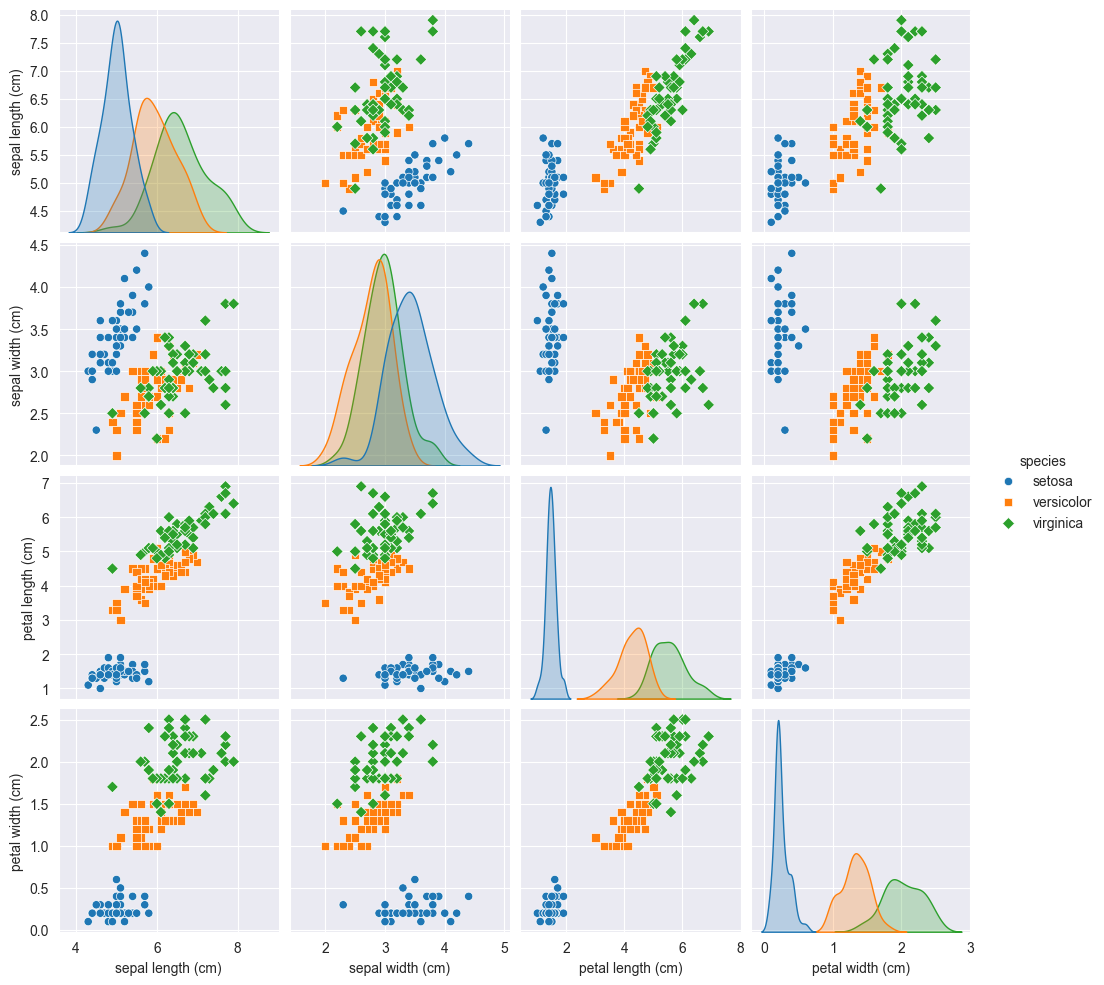

In [3]:
# visualizando o dataset com o pairplot
ax = sns.pairplot(df.drop(columns=['target']), hue='species', markers=['o', 's', 'D'])

### Usando o [LDA](https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.LinearDiscriminantAnalysis.html#sklearn.discriminant_analysis.LinearDiscriminantAnalysis)
#### Objetivo: Reduzir dimensionalidade do dataset e classificar os registros corretamente

In [4]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split

df.head()

# separar as características em X, ou seja, retirar as duas últimas colunas do dataset
X = df.iloc[:, :-2].values

# verificando a quantidade de colunas de X (apenas 4 colunas, pois retiramos 2 relacionadas à classificação)
X.shape[1]


4

In [5]:
# armazenar os registros da última coluna de df (espécies) em Y
Y = df.iloc[:, -1].values
Y.shape[0]
# Y.shape[1]

150

In [6]:
# divisão dos dados em treino (70%) e teste (30%)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)
print(f"Qtd de linhas no treino: {X_train.shape[0]}")
print(f"Qtde de colunas no treino: {X_train.shape[1]}")
print(f"Qtd de linhas no teste: {X_test.shape[0]}")
print(f"Qtde de colunas no teste: {X_test.shape[1]}")

Qtd de linhas no treino: 105
Qtde de colunas no treino: 4
Qtd de linhas no teste: 45
Qtde de colunas no teste: 4


#### Cria o modelo [LDA](https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.LinearDiscriminantAnalysis.html#sklearn.discriminant_analysis.LinearDiscriminantAnalysis)

In [7]:
# reduzindo a dimensionalidade de 4 para 2 componentes.
lda = LinearDiscriminantAnalysis(n_components=2)
print("Informações do Modelo")
lda

Informações do Modelo


,solver,'svd'
,shrinkage,None
,priors,None
,n_components,2
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


#### Treinamento

In [8]:
# treinamento
X_train_lda = lda.fit_transform(X_train, Y_train)

# obtendo um novo X para teste (X_test_lda) a partir do modelo (X_train_lda) com dimensão reduzida
X_test_lda = lda.transform(X_test)

In [9]:
# Verificando o novo X (X_train_lda) - Note que o X de treino tem 105 linhas x 2 colunas, comprovando a redução de dimensionalidade.
print(f"Quantidade de linhas de X_train: {X_train_lda.shape[0]}")
print(f"Quantidade de colunas de X_train: {X_train_lda.shape[1]}")

# Note que X_test_lda tem apenas 45 instâncias (30%) dos dados com 2 colunas, comprovando a redução de dimensão também no conjunto
print(f"Quantidade de linhas de X_test: {X_test_lda.shape[0]}")
print(f"Quantidade de colunas de X_train: {X_test_lda.shape[1]}")


Quantidade de linhas de X_train: 105
Quantidade de colunas de X_train: 2
Quantidade de linhas de X_test: 45
Quantidade de colunas de X_train: 2


In [10]:
# verificando visualmente a redução de dimensionalidade
df_lda_train = pd.DataFrame(X_train_lda, columns=['Coluna1', 'Coluna2'])

# verificando as colunas criadas pelo LDA
# df_lda_train.head()

# adicionar a classificação de espécies dos dados de treino (Y_train)
df_lda_train['species'] = Y_train

df_lda_train.head()


,Coluna1,Coluna2,species
0,-0.514612,-1.882729,versicolor
1,-3.549638,-0.715341,virginica
2,-4.527751,0.400175,virginica
3,-1.036480,0.011181,versicolor
4,-5.975968,2.759810,virginica


<Axes: xlabel='Coluna1', ylabel='Coluna2'>

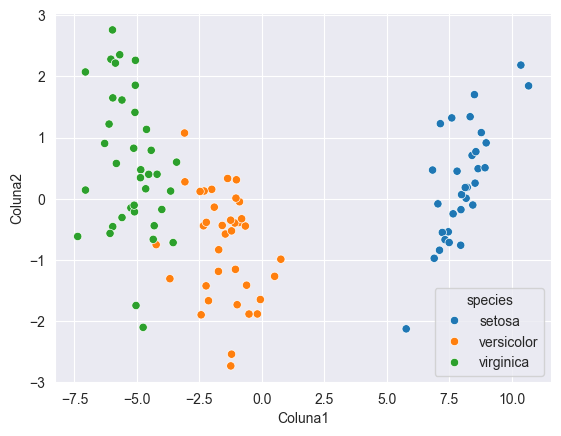

In [11]:
# verificando os valores de X_train_lda de forma ordenada
# note que após aplicação do LDA, é possível separar mais facilmente as espécies (pouco sombreamento entre virginica/versicolor)
sns.scatterplot(df_lda_train.sort_values(by='species'), x='Coluna1', y='Coluna2', hue='species')

<Axes: xlabel='Coluna1', ylabel='Coluna2'>

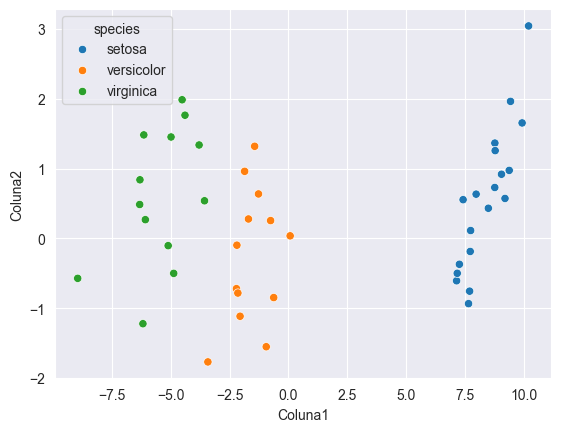

In [12]:
# repetindo para X_test
df_lda_test = pd.DataFrame(X_test_lda, columns=['Coluna1', 'Coluna2'])
df_lda_test['species'] = Y_test

# para os dados de teste, não há sombreamento entre as espécies
sns.scatterplot(df_lda_test.sort_values(by="species"), x='Coluna1', y='Coluna2', hue='species')

#### Teste (verificar predições nos dados de teste)

In [13]:
# obter as predições do treino e do teste
y_predicao_lda_train = lda.predict(X_train)
y_predicao_lda_test = lda.predict(X_test)

# adicionar ao dataframe
df_lda_train['species_predicted'] = y_predicao_lda_train
df_lda_test['species_predicted'] = y_predicao_lda_test

# verificando o dataframe de treino (e as predições)
df_lda_train.head()

,Coluna1,Coluna2,species,species_predicted
0,-0.514612,-1.882729,versicolor,versicolor
1,-3.549638,-0.715341,virginica,versicolor
2,-4.527751,0.400175,virginica,virginica
3,-1.036480,0.011181,versicolor,versicolor
4,-5.975968,2.759810,virginica,virginica


In [14]:
# verificar o dataframe de teste (e as predições)
df_lda_test.head()

,Coluna1,Coluna2,species,species_predicted
0,-2.054641,-1.115118,versicolor,versicolor
1,8.784022,1.256282,setosa,setosa
2,-8.953380,-0.572433,virginica,virginica
3,-2.189444,-0.097840,versicolor,versicolor
4,-2.208570,-0.720199,versicolor,versicolor


#### Desempenho (acurácia)

In [15]:
lda_train_acc = accuracy_score(Y_train, y_predicao_lda_train)
lda_train_acc = lda_train_acc * 100
print(f"Acurácia no treino: {lda_train_acc:.2f}%.")

lda_test_acc = accuracy_score(Y_test, y_predicao_lda_test)
lda_test_acc = lda_test_acc * 100
print(f"Acurácia no teste: {lda_test_acc:.2f}%.")
# lda_test_acc = lda_test_acc * 100

Acurácia no treino: 97.14%.
Acurácia no teste: 100.00%.


#### identificando erros dos dados preditos no treino

In [16]:
df_lda_train_erros = df_lda_train.query("species != species_predicted")

In [17]:
df_lda_train_erros.head()

,Coluna1,Coluna2,species,species_predicted
1,-3.549638,-0.715341,virginica,versicolor
44,-3.094060,1.075211,versicolor,virginica
47,-4.228972,-0.748766,versicolor,virginica


<Axes: xlabel='Coluna1', ylabel='Coluna2'>

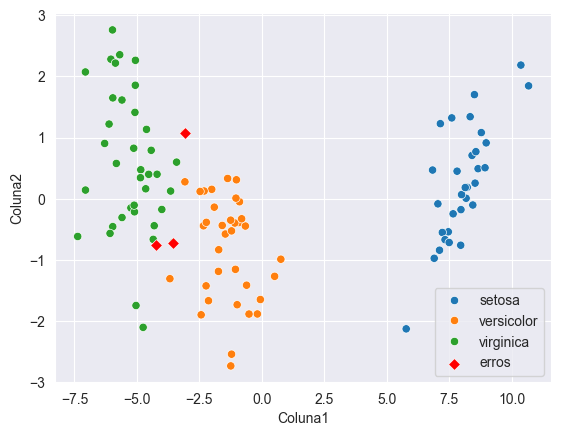

In [18]:
# plotando o gráfico com realce nos erros
sns.scatterplot(df_lda_train.sort_values(by='species'),
                x='Coluna1',
                y='Coluna2',
                hue='species')

sns.scatterplot(df_lda_train_erros.sort_values(by='species'),
                x='Coluna1',
                y='Coluna2',
                color = 'red',
                marker='D',
                label= 'erros')